In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from scipy.stats import chi2_contingency

In [ ]:
reference_data = pd.read_csv(
    r"data\processed\reference_data.csv"
)

print("Reference data shape:", reference_data.shape)

reference_data.head()

Reference data shape: (4507, 19)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,1,0,0,0,26,1,No,DSL,No,No,No,Yes,Yes,No,One year,0,Credit card (automatic),59.45,1507.00
1,1,1,1,0,72,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),116.05,8404.90
2,1,0,1,0,70,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,0,Credit card (automatic),114.30,8244.30
3,1,1,1,0,49,1,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,0,Credit card (automatic),90.05,4547.25
4,0,0,1,0,72,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),65.20,4784.45


In [ ]:
production_batches = []
production_labels = []

for i in range(1, 6):

    X_batch = pd.read_csv(
        fr"data\production\batch_{i:03d}.csv"
    )

    y_batch = pd.read_csv(
        fr"data\production\labels_{i:03d}.csv"
    )

    production_batches.append(X_batch)
    production_labels.append(
        y_batch.iloc[:, 0]
    )

    print(
        f"Batch {i}:",
        X_batch.shape,
        y_batch.shape
    )

Batch 1: (281, 19) (281, 1)
Batch 2: (281, 19) (281, 1)
Batch 3: (281, 19) (281, 1)
Batch 4: (281, 19) (281, 1)
Batch 5: (285, 19) (285, 1)


In [ ]:
production_metrics = pd.read_csv(
    r"data\processed\production_metrics.csv"
)

production_metrics

,batch_id,model_version,accuracy,precision,recall,f1,roc_auc,latency_seconds
0,batch_001,v1,0.800712,0.644737,0.628205,0.636364,0.864090,0.173268
1,batch_002,v1,0.782918,0.573770,0.500000,0.534351,0.811510,0.037735
2,batch_003,v1,0.790036,0.620253,0.628205,0.624204,0.849312,0.038704
3,batch_004,v1,0.775801,0.530864,0.632353,0.577181,0.838822,0.038333
4,batch_005,v1,0.824561,0.702703,0.650000,0.675325,0.909878,0.049086


In [ ]:
prediction_logs = pd.read_csv(
    r"data\production\prediction_logs.csv"
)

print(
    "Prediction logs shape:",
    prediction_logs.shape
)

prediction_logs.head()

Prediction logs shape: (1409, 6)


,batch_id,model_version,prediction,prediction_probability,actual_label,timestamp
0,batch_001,v1,0,0.065950,0,2026-08-28 22:23:33.281355
1,batch_001,v1,1,0.790079,0,2026-08-28 22:23:33.281355
2,batch_001,v1,0,0.112348,0,2026-08-28 22:23:33.281355
3,batch_001,v1,0,0.413663,0,2026-08-28 22:23:33.281355
4,batch_001,v1,0,0.040054,0,2026-08-28 22:23:33.281355


In [6]:
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [7]:
def calculate_psi(reference, production, bins=10):

    reference = pd.Series(reference).dropna()
    production = pd.Series(production).dropna()

    # Create bins based on reference data
    breakpoints = np.percentile(
        reference,
        np.linspace(0, 100, bins + 1)
    )

    # Remove duplicate breakpoints
    breakpoints = np.unique(breakpoints)

    # If there are not enough unique values
    if len(breakpoints) < 3:
        return 0.0

    # Histogram counts
    reference_counts = np.histogram(
        reference,
        bins=breakpoints
    )[0]

    production_counts = np.histogram(
        production,
        bins=breakpoints
    )[0]

    # Convert counts to percentages
    reference_pct = (
        reference_counts /
        len(reference)
    )

    production_pct = (
        production_counts /
        len(production)
    )

    # Avoid division by zero
    reference_pct = np.where(
        reference_pct == 0,
        0.0001,
        reference_pct
    )

    production_pct = np.where(
        production_pct == 0,
        0.0001,
        production_pct
    )

    # PSI calculation
    psi = np.sum(
        (production_pct - reference_pct) *
        np.log(
            production_pct /
            reference_pct
        )
    )

    return psi

In [8]:
def drift_status(psi):

    if psi < 0.10:
        return "No Significant Drift"

    elif psi < 0.25:
        return "Moderate Drift"

    else:
        return "Significant Drift"

In [9]:
psi = calculate_psi(
    reference_data["Monthly Charges"],
    production_batches[0]["Monthly Charges"]
)

print("Monthly Charges PSI:", psi)
print("Status:", drift_status(psi))

Monthly Charges PSI: 0.04141768342661777
Status: No Significant Drift


In [10]:
numerical_drift_results = []

for batch_number, X_batch in enumerate(
    production_batches,
    start=1
):

    for feature in numerical_features:

        psi = calculate_psi(
            reference_data[feature],
            X_batch[feature]
        )

        numerical_drift_results.append({

            "batch_id": f"batch_{batch_number:03d}",

            "feature": feature,

            "psi": psi,

            "status": drift_status(psi)
        })

In [11]:
numerical_drift_df = pd.DataFrame(
    numerical_drift_results
)

numerical_drift_df

,batch_id,feature,psi,status
0,batch_001,Tenure Months,0.061439,No Significant Drift
1,batch_001,Monthly Charges,0.041418,No Significant Drift
2,batch_001,Total Charges,0.075798,No Significant Drift
3,batch_002,Tenure Months,0.017818,No Significant Drift
4,batch_002,Monthly Charges,0.022588,No Significant Drift
5,batch_002,Total Charges,0.015007,No Significant Drift
6,batch_003,Tenure Months,0.034415,No Significant Drift
7,batch_003,Monthly Charges,0.085334,No Significant Drift
8,batch_003,Total Charges,0.028591,No Significant Drift
9,batch_004,Tenure Months,0.031496,No Significant Drift


In [12]:
numerical_drift_df.sort_values(
    by="psi",
    ascending=False
)

,batch_id,feature,psi,status
7,batch_003,Monthly Charges,0.085334,No Significant Drift
2,batch_001,Total Charges,0.075798,No Significant Drift
0,batch_001,Tenure Months,0.061439,No Significant Drift
1,batch_001,Monthly Charges,0.041418,No Significant Drift
12,batch_005,Tenure Months,0.039982,No Significant Drift
6,batch_003,Tenure Months,0.034415,No Significant Drift
9,batch_004,Tenure Months,0.031496,No Significant Drift
8,batch_003,Total Charges,0.028591,No Significant Drift
10,batch_004,Monthly Charges,0.023901,No Significant Drift
4,batch_002,Monthly Charges,0.022588,No Significant Drift


In [13]:
def calculate_categorical_drift(
    reference,
    production
):

    reference_counts = (
        reference
        .value_counts()
    )

    production_counts = (
        production
        .value_counts()
    )

    categories = set(
        reference_counts.index
    ).union(
        production_counts.index
    )

    reference_counts = (
        reference_counts
        .reindex(
            categories,
            fill_value=0
        )
    )

    production_counts = (
        production_counts
        .reindex(
            categories,
            fill_value=0
        )
    )

    contingency_table = np.array([
        reference_counts.values,
        production_counts.values
    ])

    chi2, p_value, _, _ = chi2_contingency(
        contingency_table
    )

    return p_value

In [14]:
def categorical_drift_status(p_value):

    if p_value < 0.05:
        return "Drift Detected"

    return "No Significant Drift"

In [15]:
categorical_drift_results = []

for batch_number, X_batch in enumerate(
    production_batches,
    start=1
):

    for feature in categorical_features:

        p_value = calculate_categorical_drift(
            reference_data[feature],
            X_batch[feature]
        )

        categorical_drift_results.append({

            "batch_id": f"batch_{batch_number:03d}",

            "feature": feature,

            "p_value": p_value,

            "status": categorical_drift_status(
                p_value
            )
        })

In [16]:
categorical_drift_df = pd.DataFrame(
    categorical_drift_results
)

categorical_drift_df

,batch_id,feature,p_value,status
0,batch_001,Gender,0.653509,No Significant Drift
1,batch_001,Senior Citizen,0.884918,No Significant Drift
2,batch_001,Partner,0.926106,No Significant Drift
3,batch_001,Dependents,0.884804,No Significant Drift
4,batch_001,Phone Service,0.516035,No Significant Drift
...,...,...,...,...
75,batch_005,Streaming TV,0.655446,No Significant Drift
76,batch_005,Streaming Movies,0.674197,No Significant Drift
77,batch_005,Contract,0.764928,No Significant Drift
78,batch_005,Paperless Billing,0.942202,No Significant Drift


In [17]:
categorical_summary = (
    categorical_drift_df
    .groupby("batch_id")
    .agg(
        categorical_drift_features=(
            "status",
            lambda x: (
                x == "Drift Detected"
            ).sum()
        )
    )
    .reset_index()
)

categorical_summary

,batch_id,categorical_drift_features
0,batch_001,0
1,batch_002,2
2,batch_003,1
3,batch_004,0
4,batch_005,1


In [18]:
numerical_summary = (
    numerical_drift_df
    .groupby("batch_id")
    .agg(
        max_numerical_psi=("psi", "max"),
        numerical_drift_features=(
            "status",
            lambda x: (
                x != "No Significant Drift"
            ).sum()
        )
    )
    .reset_index()
)

numerical_summary

,batch_id,max_numerical_psi,numerical_drift_features
0,batch_001,0.075798,0
1,batch_002,0.022588,0
2,batch_003,0.085334,0
3,batch_004,0.031496,0
4,batch_005,0.039982,0


In [19]:
drift_summary = numerical_summary.merge(
    categorical_summary,
    on="batch_id",
    how="left"
)

drift_summary

,batch_id,max_numerical_psi,numerical_drift_features,categorical_drift_features
0,batch_001,0.075798,0,0
1,batch_002,0.022588,0,2
2,batch_003,0.085334,0,1
3,batch_004,0.031496,0,0
4,batch_005,0.039982,0,1


In [20]:
def overall_drift_status(row):

    if (
        row["max_numerical_psi"] >= 0.25
        or
        row["categorical_drift_features"] >= 3
    ):
        return "DRIFT DETECTED"

    return "HEALTHY"

In [21]:
drift_summary["drift_status"] = (
    drift_summary.apply(
        overall_drift_status,
        axis=1
    )
)

In [22]:
drift_summary

,batch_id,max_numerical_psi,numerical_drift_features,categorical_drift_features,drift_status
0,batch_001,0.075798,0,0,HEALTHY
1,batch_002,0.022588,0,2,HEALTHY
2,batch_003,0.085334,0,1,HEALTHY
3,batch_004,0.031496,0,0,HEALTHY
4,batch_005,0.039982,0,1,HEALTHY


In [23]:
production_metrics.columns

Index(['batch_id', 'model_version', 'accuracy', 'precision', 'recall', 'f1',
       'roc_auc', 'latency_seconds'],
      dtype='str')

In [24]:
production_metrics[
    [
        "batch_id",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
]

,batch_id,accuracy,precision,recall,f1,roc_auc
0,batch_001,0.800712,0.644737,0.628205,0.636364,0.864090
1,batch_002,0.782918,0.573770,0.500000,0.534351,0.811510
2,batch_003,0.790036,0.620253,0.628205,0.624204,0.849312
3,batch_004,0.775801,0.530864,0.632353,0.577181,0.838822
4,batch_005,0.824561,0.702703,0.650000,0.675325,0.909878


In [25]:
baseline_f1 = 0.63
performance_threshold = baseline_f1 * 0.90

print(
    "Performance threshold:",
    performance_threshold
)

Performance threshold: 0.5670000000000001


In [26]:
production_metrics["performance_status"] = (
    production_metrics["f1"]
    .apply(
        lambda f1:
        "Healthy"
        if f1 >= performance_threshold
        else "Degraded"
    )
)

In [27]:
production_metrics[
    [
        "batch_id",
        "f1",
        "performance_status"
    ]
]

,batch_id,f1,performance_status
0,batch_001,0.636364,Healthy
1,batch_002,0.534351,Degraded
2,batch_003,0.624204,Healthy
3,batch_004,0.577181,Healthy
4,batch_005,0.675325,Healthy


In [28]:
production_metrics["f1_degradation_pct"] = (
    (
        baseline_f1 -
        production_metrics["f1"]
    )
    /
    baseline_f1
) * 100

In [29]:
production_metrics[
    [
        "batch_id",
        "f1",
        "f1_degradation_pct",
        "performance_status"
    ]
]

,batch_id,f1,f1_degradation_pct,performance_status
0,batch_001,0.636364,-1.010101,Healthy
1,batch_002,0.534351,15.182358,Degraded
2,batch_003,0.624204,0.920028,Healthy
3,batch_004,0.577181,8.383935,Healthy
4,batch_005,0.675325,-7.194393,Healthy


In [30]:
monitoring_report = drift_summary.merge(
    production_metrics[
        [
            "batch_id",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "performance_status",
            "f1_degradation_pct"
        ]
    ],
    on="batch_id",
    how="left"
)

In [31]:
monitoring_report

,batch_id,max_numerical_psi,numerical_drift_features,categorical_drift_features,drift_status,accuracy,precision,recall,f1,roc_auc,performance_status,f1_degradation_pct
0,batch_001,0.075798,0,0,HEALTHY,0.800712,0.644737,0.628205,0.636364,0.864090,Healthy,-1.010101
1,batch_002,0.022588,0,2,HEALTHY,0.782918,0.573770,0.500000,0.534351,0.811510,Degraded,15.182358
2,batch_003,0.085334,0,1,HEALTHY,0.790036,0.620253,0.628205,0.624204,0.849312,Healthy,0.920028
3,batch_004,0.031496,0,0,HEALTHY,0.775801,0.530864,0.632353,0.577181,0.838822,Healthy,8.383935
4,batch_005,0.039982,0,1,HEALTHY,0.824561,0.702703,0.650000,0.675325,0.909878,Healthy,-7.194393


In [32]:
def reliability_status(row):

    drift = (
        row["drift_status"]
        == "DRIFT DETECTED"
    )

    performance = (
        row["performance_status"]
        == "Degraded"
    )

    if drift and performance:
        return "CRITICAL"

    elif drift:
        return "DRIFT DETECTED"

    elif performance:
        return "PERFORMANCE DEGRADATION"

    else:
        return "HEALTHY"

In [33]:
monitoring_report["reliability_status"] = (
    monitoring_report.apply(
        reliability_status,
        axis=1
    )
)

In [34]:
final_report = monitoring_report[
    [
        "batch_id",
        "max_numerical_psi",
        "numerical_drift_features",
        "categorical_drift_features",
        "drift_status",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "f1_degradation_pct",
        "performance_status",
        "reliability_status"
    ]
]

final_report

,batch_id,max_numerical_psi,numerical_drift_features,categorical_drift_features,drift_status,accuracy,precision,recall,f1,roc_auc,f1_degradation_pct,performance_status,reliability_status
0,batch_001,0.075798,0,0,HEALTHY,0.800712,0.644737,0.628205,0.636364,0.864090,-1.010101,Healthy,HEALTHY
1,batch_002,0.022588,0,2,HEALTHY,0.782918,0.573770,0.500000,0.534351,0.811510,15.182358,Degraded,PERFORMANCE DEGRADATION
2,batch_003,0.085334,0,1,HEALTHY,0.790036,0.620253,0.628205,0.624204,0.849312,0.920028,Healthy,HEALTHY
3,batch_004,0.031496,0,0,HEALTHY,0.775801,0.530864,0.632353,0.577181,0.838822,8.383935,Healthy,HEALTHY
4,batch_005,0.039982,0,1,HEALTHY,0.824561,0.702703,0.650000,0.675325,0.909878,-7.194393,Healthy,HEALTHY


In [35]:
attention_required = final_report[
    final_report["reliability_status"]
    != "HEALTHY"
]

attention_required

,batch_id,max_numerical_psi,numerical_drift_features,categorical_drift_features,drift_status,accuracy,precision,recall,f1,roc_auc,f1_degradation_pct,performance_status,reliability_status
1,batch_002,0.022588,0,2,HEALTHY,0.782918,0.57377,0.5,0.534351,0.81151,15.182358,Degraded,PERFORMANCE DEGRADATION


In [36]:
def retraining_signal(status):

    if status == "CRITICAL":
        return "RETRAIN"

    elif status == "PERFORMANCE DEGRADATION":
        return "RETRAIN"

    elif status == "DRIFT DETECTED":
        return "MONITOR"

    else:
        return "NO ACTION"

In [37]:
final_report["retraining_signal"] = (
    final_report["reliability_status"]
    .apply(retraining_signal)
)

In [38]:
final_report

,batch_id,max_numerical_psi,numerical_drift_features,categorical_drift_features,drift_status,accuracy,precision,recall,f1,roc_auc,f1_degradation_pct,performance_status,reliability_status,retraining_signal
0,batch_001,0.075798,0,0,HEALTHY,0.800712,0.644737,0.628205,0.636364,0.864090,-1.010101,Healthy,HEALTHY,NO ACTION
1,batch_002,0.022588,0,2,HEALTHY,0.782918,0.573770,0.500000,0.534351,0.811510,15.182358,Degraded,PERFORMANCE DEGRADATION,RETRAIN
2,batch_003,0.085334,0,1,HEALTHY,0.790036,0.620253,0.628205,0.624204,0.849312,0.920028,Healthy,HEALTHY,NO ACTION
3,batch_004,0.031496,0,0,HEALTHY,0.775801,0.530864,0.632353,0.577181,0.838822,8.383935,Healthy,HEALTHY,NO ACTION
4,batch_005,0.039982,0,1,HEALTHY,0.824561,0.702703,0.650000,0.675325,0.909878,-7.194393,Healthy,HEALTHY,NO ACTION


In [ ]:
final_report.to_csv(
    r"data\processed\week3_monitoring_report.csv",
    index=False
)

In [ ]:
numerical_drift_df.to_csv(
    r"data\processed\numerical_drift.csv",
    index=False
)

In [ ]:
categorical_drift_df.to_csv(
    r"data\processed\categorical_drift.csv",
    index=False
)

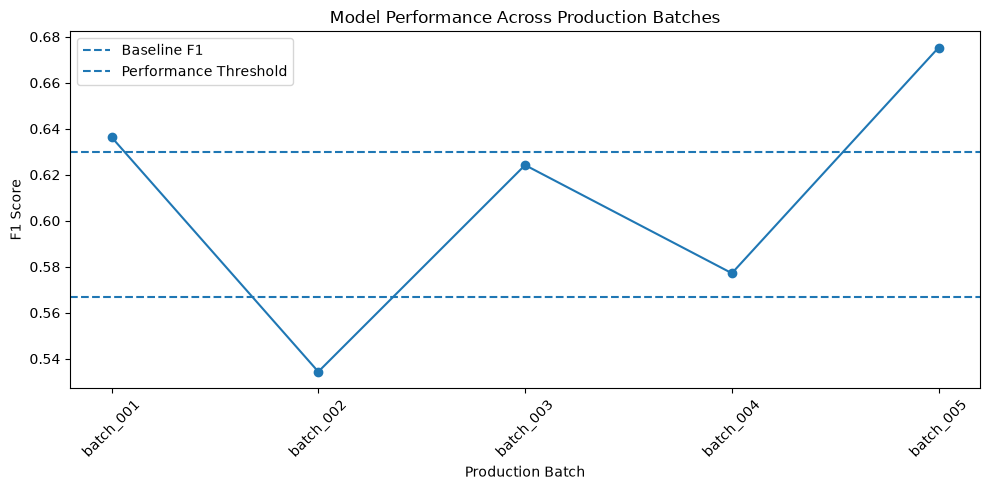

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    final_report["batch_id"],
    final_report["f1"],
    marker="o"
)

plt.axhline(
    y=baseline_f1,
    linestyle="--",
    label="Baseline F1"
)

plt.axhline(
    y=performance_threshold,
    linestyle="--",
    label="Performance Threshold"
)

plt.xlabel("Production Batch")
plt.ylabel("F1 Score")
plt.title("Model Performance Across Production Batches")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

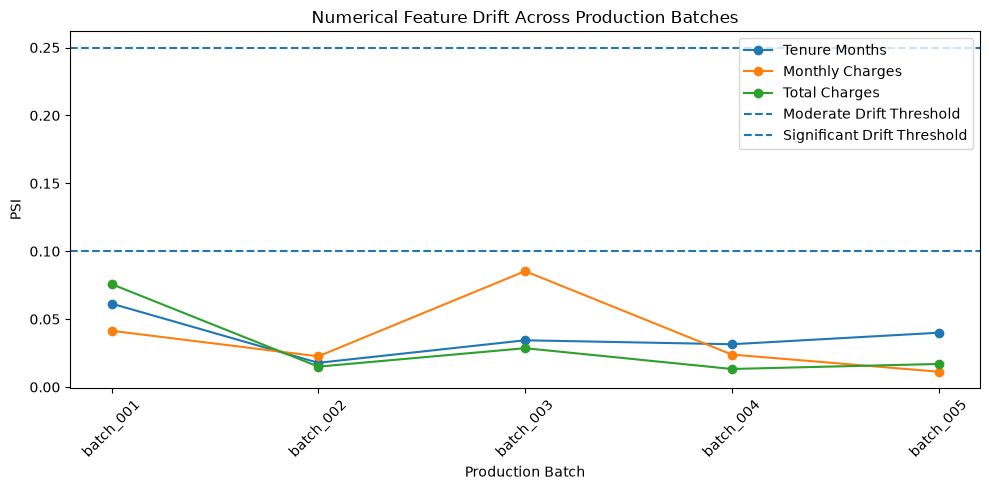

In [43]:
plt.figure(figsize=(10, 5))

for feature in numerical_features:

    feature_data = numerical_drift_df[
        numerical_drift_df["feature"] == feature
    ]

    plt.plot(
        feature_data["batch_id"],
        feature_data["psi"],
        marker="o",
        label=feature
    )

plt.axhline(
    y=0.10,
    linestyle="--",
    label="Moderate Drift Threshold"
)

plt.axhline(
    y=0.25,
    linestyle="--",
    label="Significant Drift Threshold"
)

plt.xlabel("Production Batch")
plt.ylabel("PSI")

plt.title(
    "Numerical Feature Drift Across Production Batches"
)

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()